<a href="https://colab.research.google.com/github/geovanneaoliveira/Projeto-Especializado/blob/main/train_yolo_cocacola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO26 Training — Coca Cola Bottle Dataset

**Dataset:** `My Drive/Projeto Especializado/datasets/Coca Cola Bottle.v14i.yolo`  
**Model:** YOLO26 (Ultralytics, released Sep 2025)  
**Runtime:** GPU recommended (Runtime > Change runtime type > T4 GPU)

> **YOLO26 highlights:** NMS-free end-to-end inference, no DFL, MuSGD optimizer, ProgLoss + STAL label assignment. Up to 43% faster CPU inference vs YOLO11.

---

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install Ultralytics (YOLOv8)

In [ ]:
# YOLO26 requires ultralytics >= 8.3.x (released Sep 2025)
%pip install -U ultralytics -q

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
ultralytics.checks()  # Verifies GPU, CUDA, and library versions

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


## 3. Define Dataset Path and Fix data.yaml

In [ ]:
import os
import yaml
import shutil

# ── Paths ──────────────────────────────────────────────────────────────────
DRIVE_DATASET = "/content/drive/MyDrive/Projeto Especializado/datasets/Coca Cola Bottle.v14i.yolo26"
LOCAL_DATASET = "/content/datasets/cocacola"         # fast local copy for training
YAML_PATH     = os.path.join(LOCAL_DATASET, "data.yaml")
RUNS_DIR      = "/content/drive/MyDrive/Projeto Especializado/runs"  # save results back to Drive

# ── Copy dataset to local SSD (much faster I/O than Drive) ─────────────────
if os.path.exists(LOCAL_DATASET):
    shutil.rmtree(LOCAL_DATASET)

print("📂 Copying dataset to local storage...")
shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)
print(f"✅ Dataset copied to: {LOCAL_DATASET}")

# ── List contents ──────────────────────────────────────────────────────────
print("\nDataset contents:")
for item in sorted(os.listdir(LOCAL_DATASET)):
    print(f"  {item}")

📂 Copying dataset to local storage...
✅ Dataset copied to: /content/datasets/cocacola

Dataset contents:
  README.dataset.txt
  README.roboflow.txt
  data.yaml
  test
  train
  valid


In [ ]:
# ── Patch data.yaml so all paths point to the local copy ───────────────────
with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

print("Original data.yaml:")
print(yaml.dump(data_cfg))

# Update path to local dataset root
data_cfg["path"] = LOCAL_DATASET

# Ensure train/val/test keys exist (Roboflow exports usually include them)
for split in ["train", "val", "test"]:
    if split not in data_cfg:
        candidate = os.path.join(LOCAL_DATASET, split, "images")
        if os.path.exists(candidate):
            data_cfg[split] = f"{split}/images"

with open(YAML_PATH, "w") as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print("\nPatched data.yaml:")
print(yaml.dump(data_cfg))

Original data.yaml:
names:
- Garrafa normal
- Defeito Encontrado - rotulo
- Defeito Encontrado - sem_tampa
- Defeito Encontrado - tampa_nao_lacrada
- Defeito Encontrado - liquido_abaixo
nc: 5
roboflow:
  license: CC BY 4.0
  project: coca-cola-bottle
  url: https://universe.roboflow.com/coca-cola-bottle/coca-cola-bottle/dataset/14
  version: 14
  workspace: coca-cola-bottle
test: ../test/images
train: ../train/images
val: ../valid/images


Patched data.yaml:
names:
- Garrafa normal
- Defeito Encontrado - rotulo
- Defeito Encontrado - sem_tampa
- Defeito Encontrado - tampa_nao_lacrada
- Defeito Encontrado - liquido_abaixo
nc: 5
path: /content/datasets/cocacola
roboflow:
  license: CC BY 4.0
  project: coca-cola-bottle
  url: https://universe.roboflow.com/coca-cola-bottle/coca-cola-bottle/dataset/14
  version: 14
  workspace: coca-cola-bottle
test: ../test/images
train: ../train/images
val: ../valid/images



## 4. Configure Training Parameters

In [ ]:
# ── Training configuration ─────────────────────────────────────────────────
# YOLO26 model variants:
#   yolo26n.pt  — nano  (2.4M params, fastest, ~40.9 mAP)  ← great for Colab free tier
#   yolo26s.pt  — small (9.5M params, ~48.6 mAP)
#   yolo26m.pt  — medium (20.4M params, ~53.1 mAP)         ← good balance on T4
#   yolo26l.pt  — large (~54.3 mAP)
#   yolo26x.pt  — xlarge (~56.8 mAP, slowest)
#
# YOLO26 key differences vs older YOLO:
#   - NMS-free end-to-end inference (one-to-one head by default)
#   - No DFL (Distribution Focal Loss) — simpler, faster
#   - MuSGD optimizer built-in (use optimizer='MuSGD' for best results)
#   - ProgLoss + STAL label assignment (better small-object accuracy)

TRAIN_CONFIG = dict(
    model         = "yolo26m.pt",
    data          = YAML_PATH,
    epochs        = 200,
    imgsz         = 640,          # resolução alta para defeitos sutis
    batch         = 16,             # reduzido por causa do imgsz maior
    #patience      = 80,            # early stopping reativado
    optimizer     = "MuSGD",
    lr0           = 1e-2,
    lrf           = 0.01,
    momentum      = 0.937,
    weight_decay  = 5e-4,
    warmup_epochs = 3,
    cos_lr        = True,
    augment       = True,
    degrees       = 5.0,           # rotação conservadora
    flipud        = 0.0,
    fliplr        = 0.0,           # lacres têm direção — sem espelhamento
    hsv_h         = 0.015,
    hsv_s         = 0.4,           # saturação menos agressiva
    hsv_v         = 0.4,
    mosaic        = 1.0,           # mosaico mantido — ajuda com variação de fundo
    mixup         = 0.0,           # removido — cria artefatos irreais no líquido
    copy_paste    = 0.0,           # removido — contexto industrial controlado
    workers       = 4,
    device        = 0,
    project       = RUNS_DIR,
    name          = "cocacola_yolo26m_inspecao_v1",
    exist_ok      = True,
    pretrained    = True,
    verbose       = True,
)

print("Training config:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k:20s}: {v}")

Training config:
  model               : yolo26m.pt
  data                : /content/datasets/cocacola/data.yaml
  epochs              : 200
  imgsz               : 640
  batch               : 16
  optimizer           : MuSGD
  lr0                 : 0.01
  lrf                 : 0.01
  momentum            : 0.937
  weight_decay        : 0.0005
  warmup_epochs       : 3
  cos_lr              : True
  augment             : True
  degrees             : 5.0
  flipud              : 0.0
  fliplr              : 0.0
  hsv_h               : 0.015
  hsv_s               : 0.4
  hsv_v               : 0.4
  mosaic              : 1.0
  mixup               : 0.0
  copy_paste          : 0.0
  workers             : 4
  device              : 0
  project             : /content/drive/MyDrive/Projeto Especializado/runs
  name                : cocacola_yolo26m_inspecao_v1
  exist_ok            : True
  pretrained          : True
  verbose             : True


## 5. Train the Model

In [ ]:
from ultralytics import YOLO

os.makedirs(RUNS_DIR, exist_ok=True)

model = YOLO(TRAIN_CONFIG.pop("model"))
results = model.train(**TRAIN_CONFIG)

print("\n✅ Training complete!")
print(f"Best weights saved to: {results.save_dir}/weights/best.pt")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/cocacola/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cocacola_yolo26m_inspecao_v1, nbs=64, nms=False, opset=None, optimize=F

## 6. Evaluate on Validation Set

In [ ]:
best_weights = os.path.join(results.save_dir, "weights", "best.pt")
eval_model = YOLO(best_weights)

metrics = eval_model.val(data=YAML_PATH, imgsz=640, batch=16)

print("\n📊 Validation metrics:")
print(f"  mAP50      : {metrics.box.map50:.4f}")
print(f"  mAP50-95   : {metrics.box.map:.4f}")
print(f"  Precision  : {metrics.box.mp:.4f}")
print(f"  Recall     : {metrics.box.mr:.4f}")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,353,307 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1325.6±657.1 MB/s, size: 53.7 KB)
val: Scanning /content/datasets/cocacola/valid/labels.cache... 161 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 56.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 64, len(boxes) = 170. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.4it/s 4.7s
                   all        161        170      0.931      0.942      0.939      0.745
        Garrafa normal         60         60      0.918          1      0.988      0.939
Defeito Encontrado - rotulo   

## 7. Plot Training Curves


📈 results.png


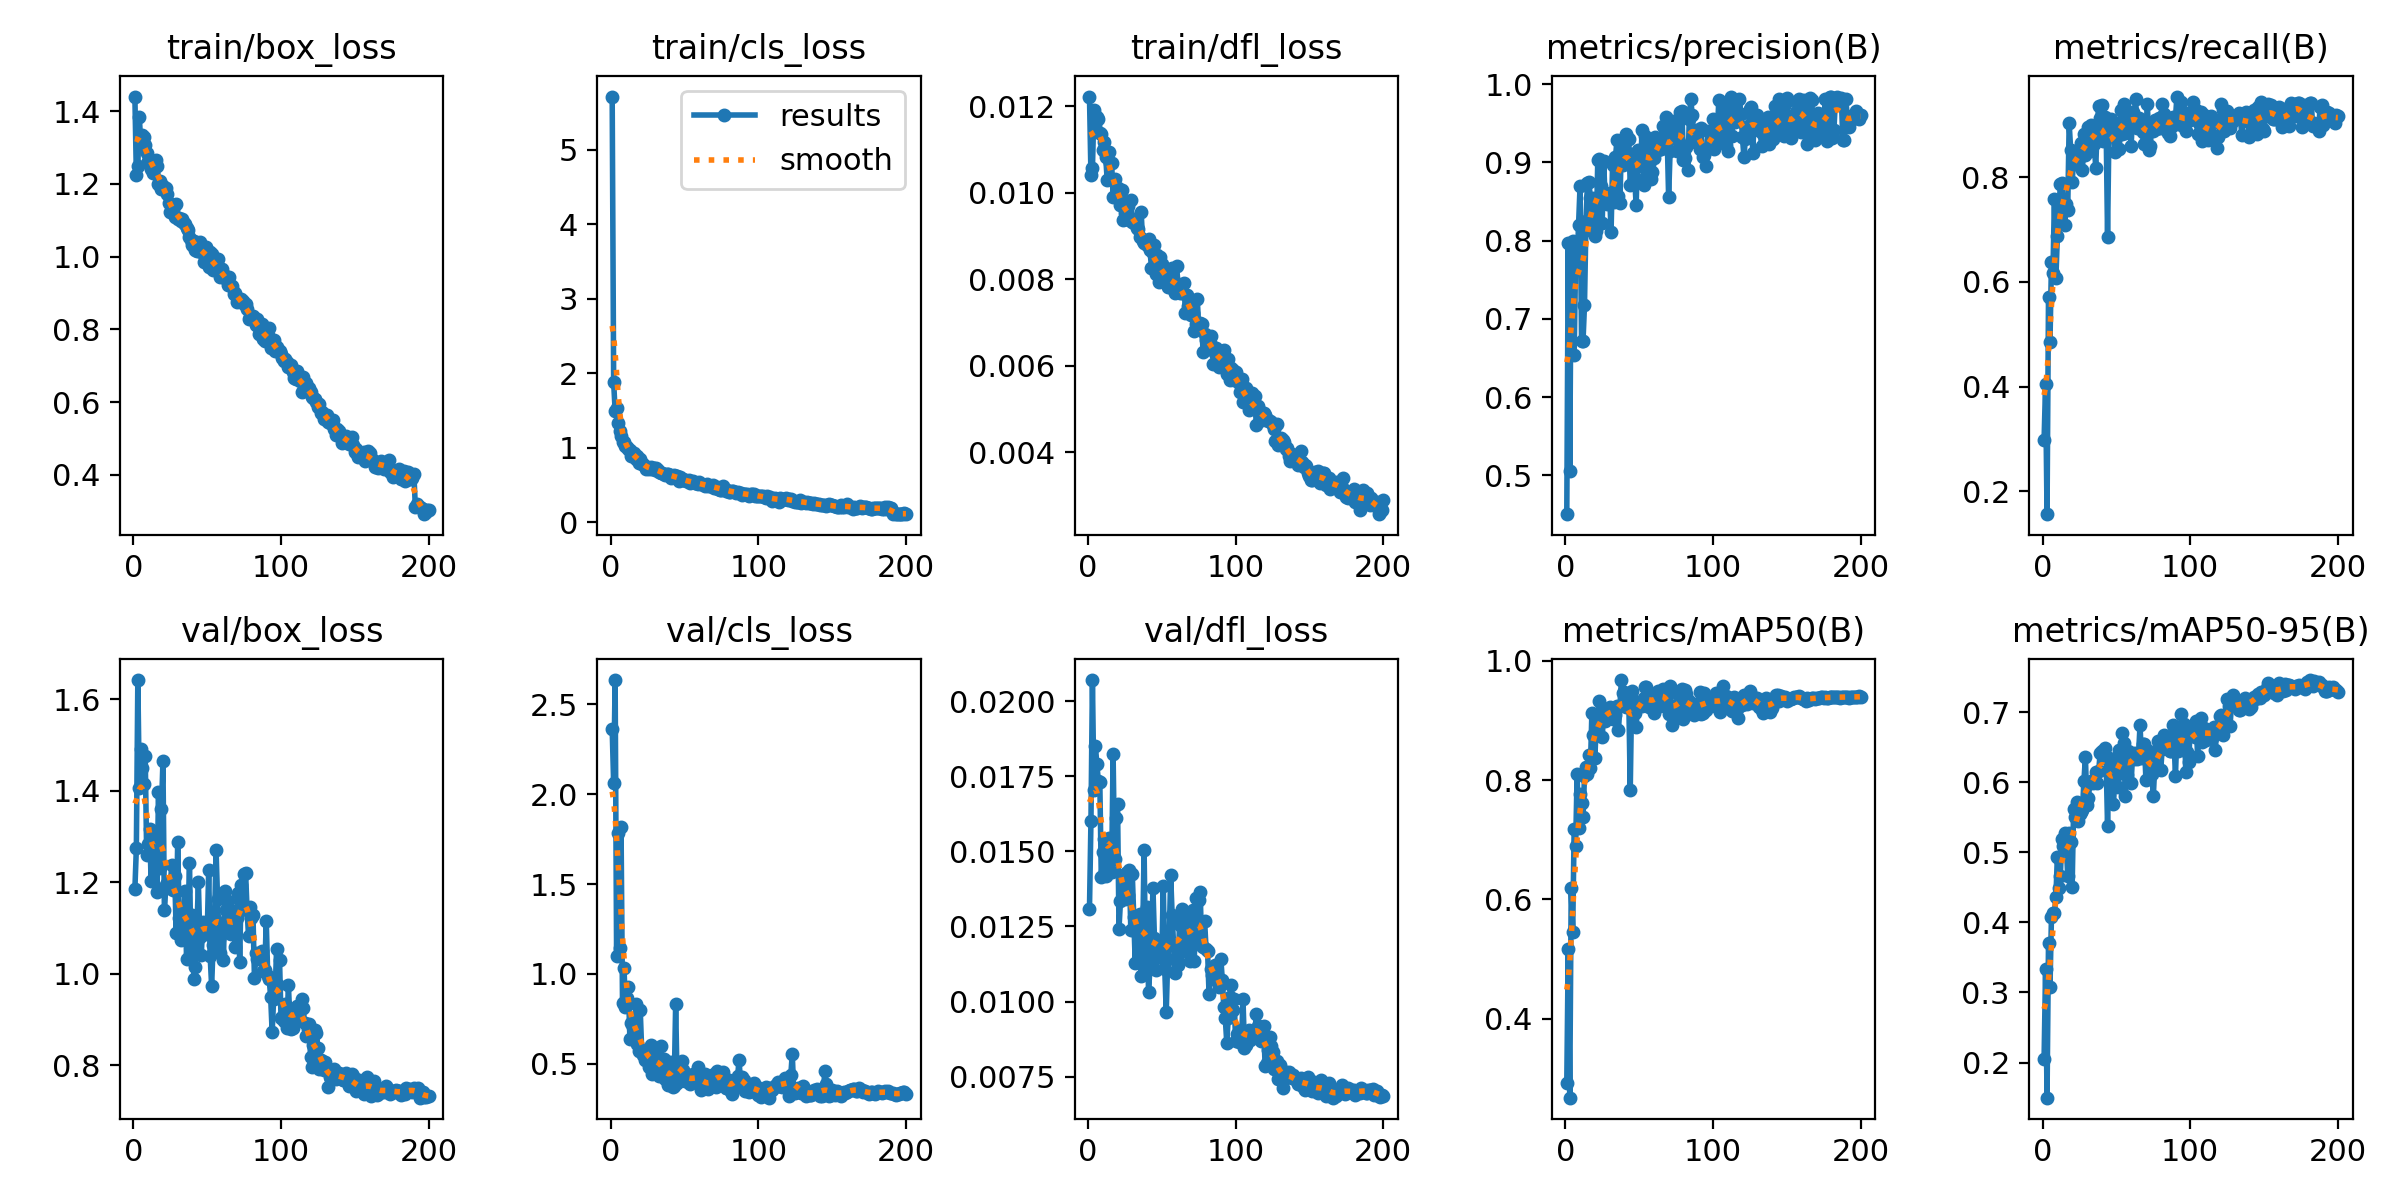


📈 confusion_matrix.png


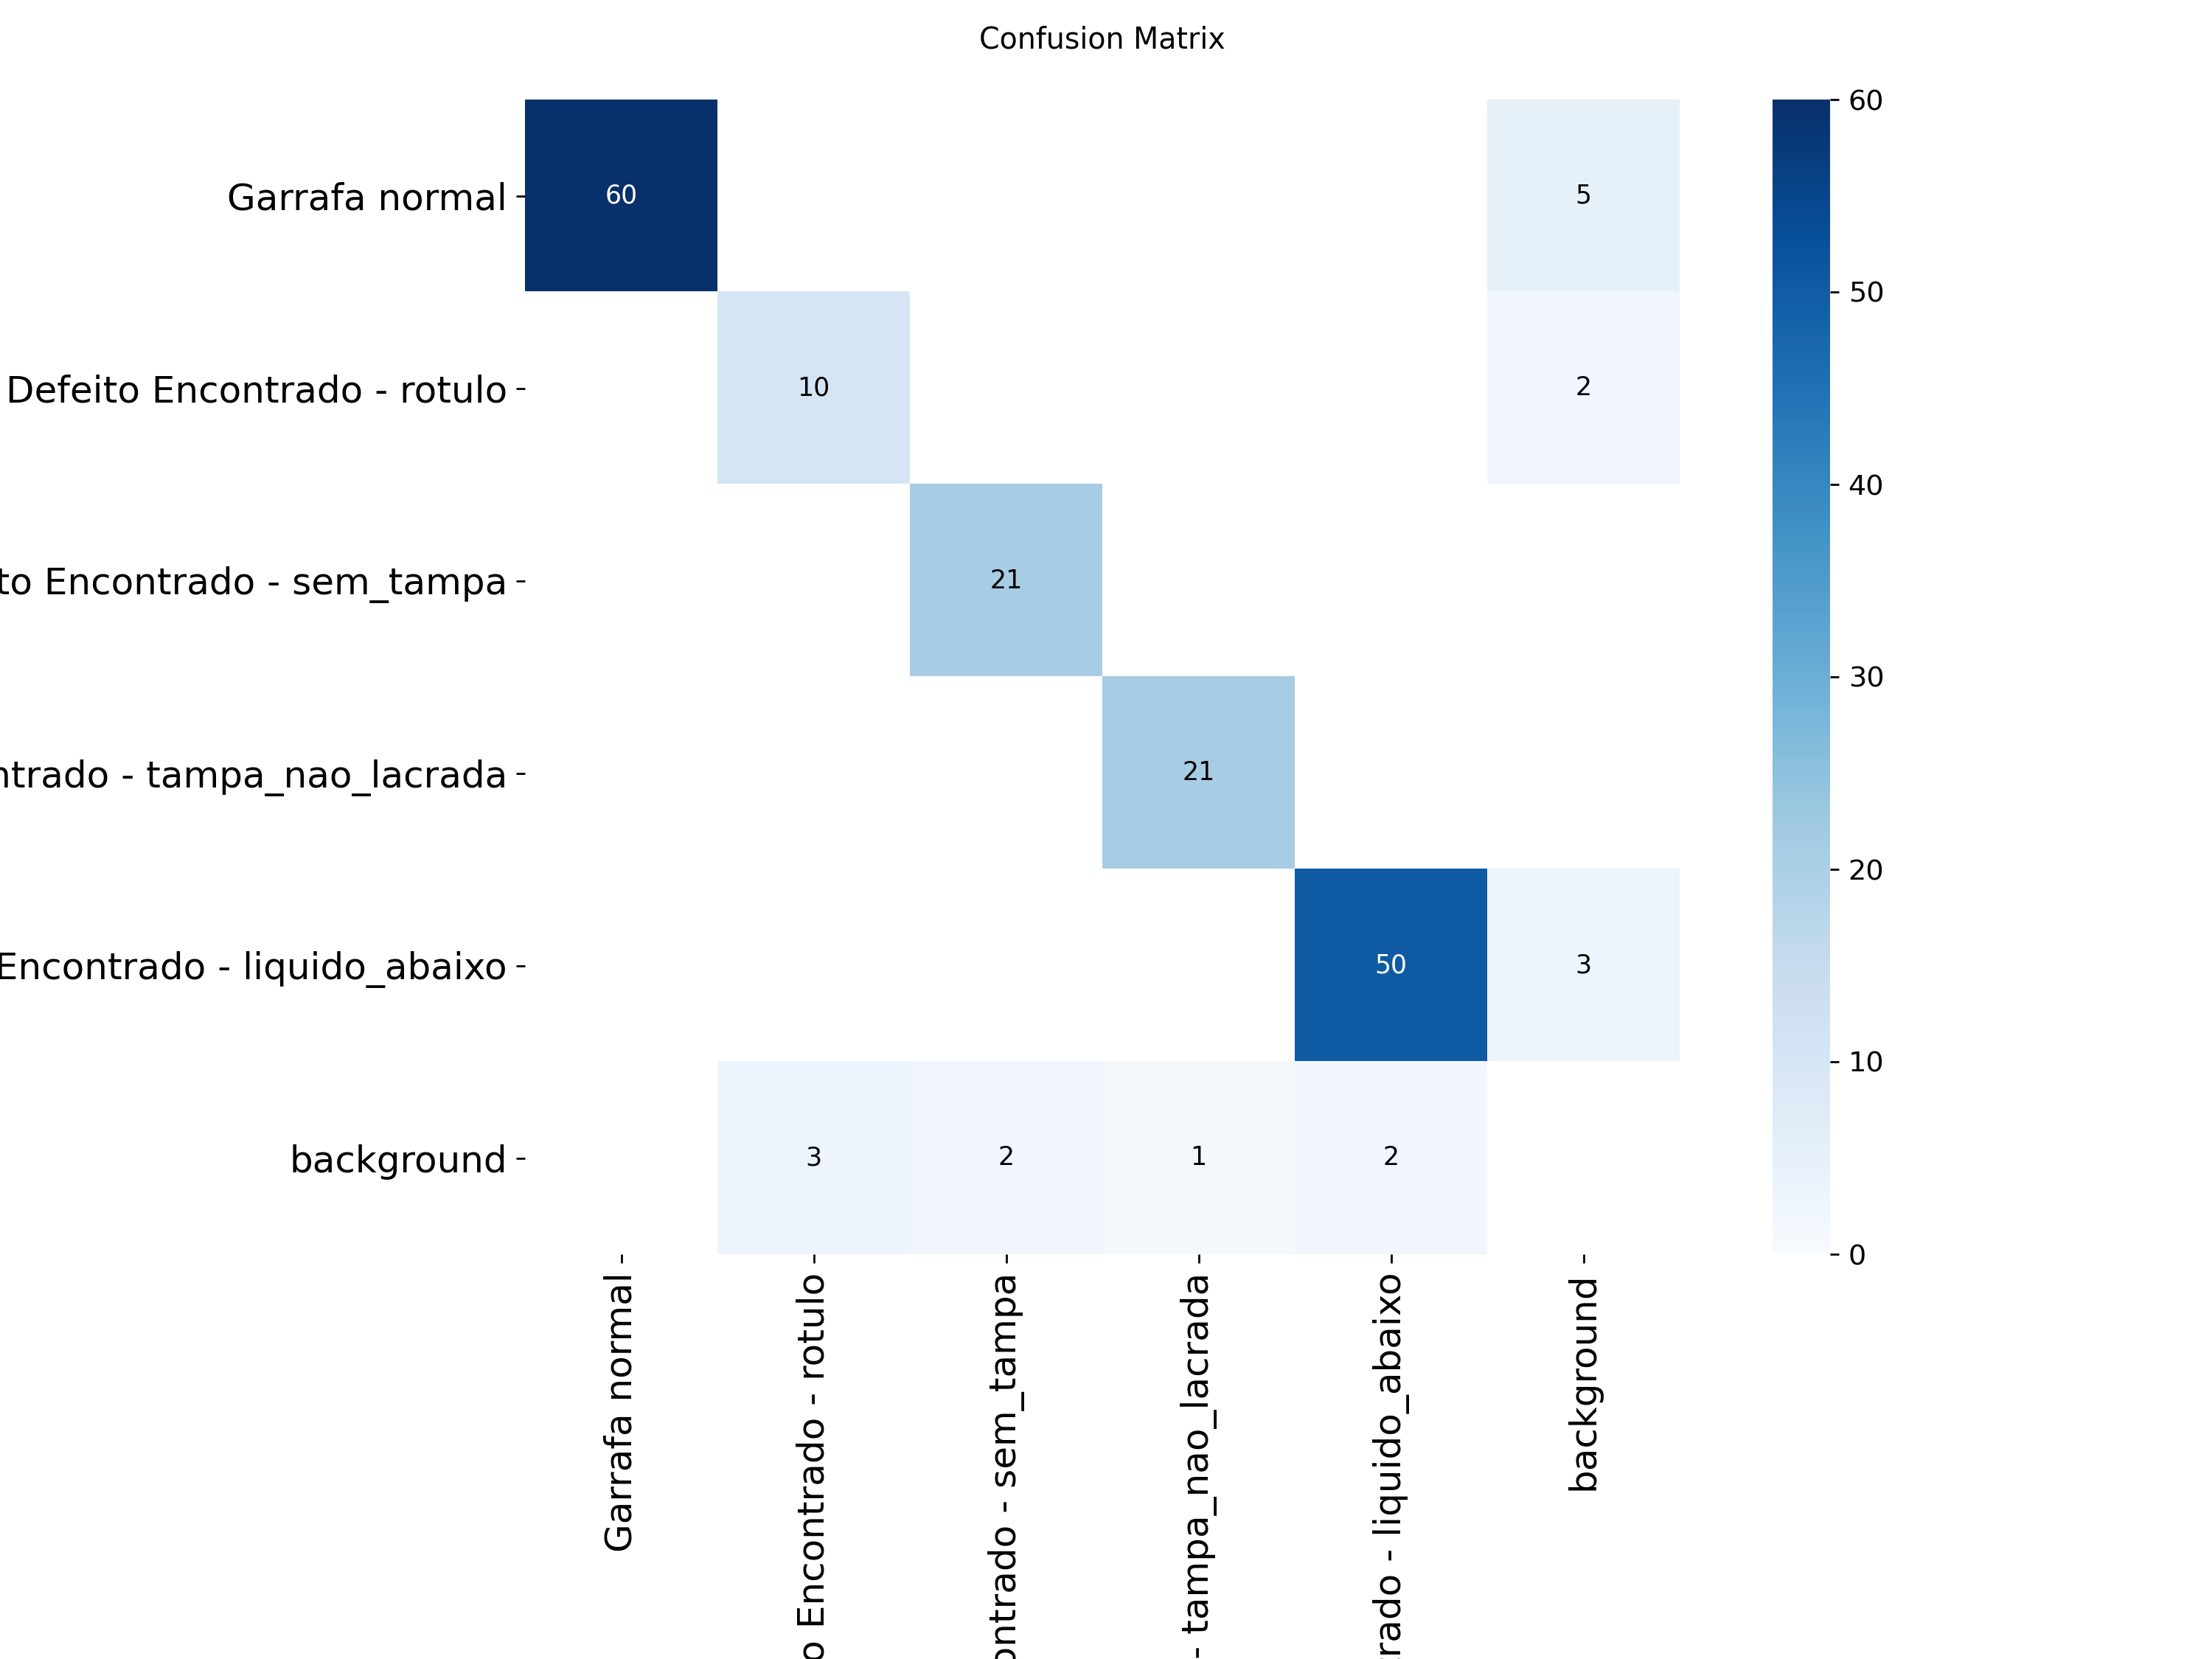

In [ ]:
from IPython.display import Image, display
import glob

save_dir = str(results.save_dir)

for plot_file in ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
    path = os.path.join(save_dir, plot_file)
    if os.path.exists(path):
        print(f"\n📈 {plot_file}")
        display(Image(path))

## 8. Run Inference on Test Images


0: 640x480 1 Garrafa normal, 25.0ms
1: 640x480 1 Defeito Encontrado - rotulo, 1 Defeito Encontrado - liquido_abaixo, 25.0ms
2: 640x480 1 Garrafa normal, 25.0ms
3: 640x480 1 Defeito Encontrado - tampa_nao_lacrada, 25.0ms
4: 640x480 1 Defeito Encontrado - tampa_nao_lacrada, 25.0ms
Speed: 1.5ms preprocess, 25.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/Projeto Especializado/runs/cocacola_predictions

🖼 image4.jpg


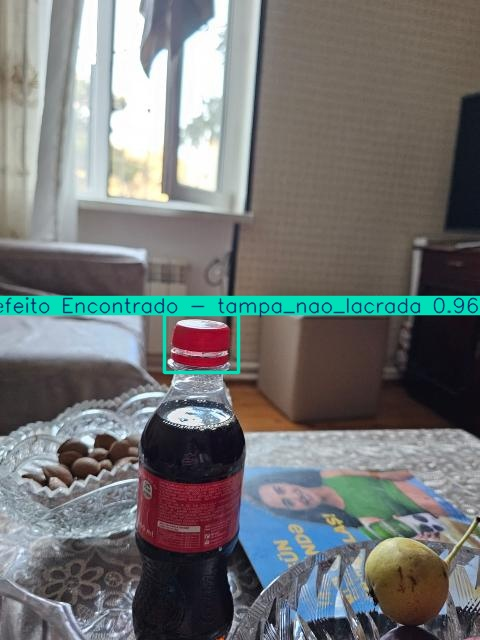


🖼 image2.jpg


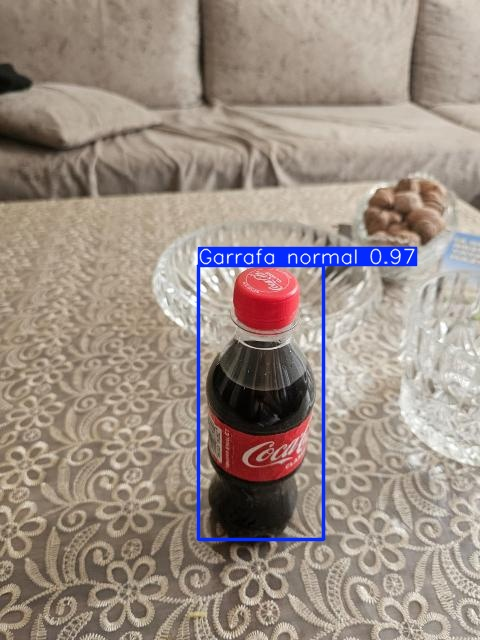


🖼 image3.jpg


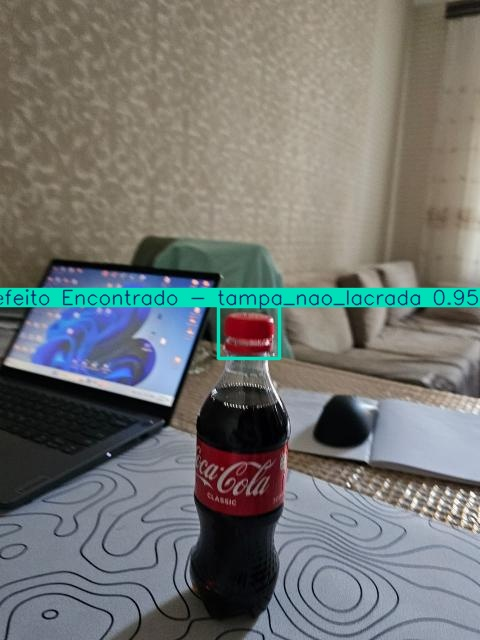


🖼 image1.jpg


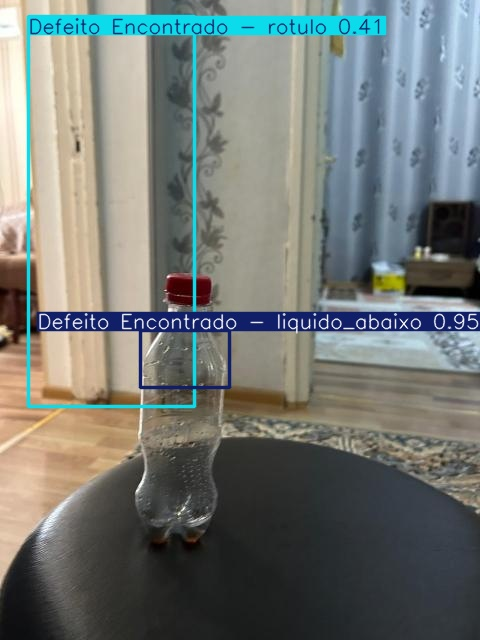


🖼 image0.jpg


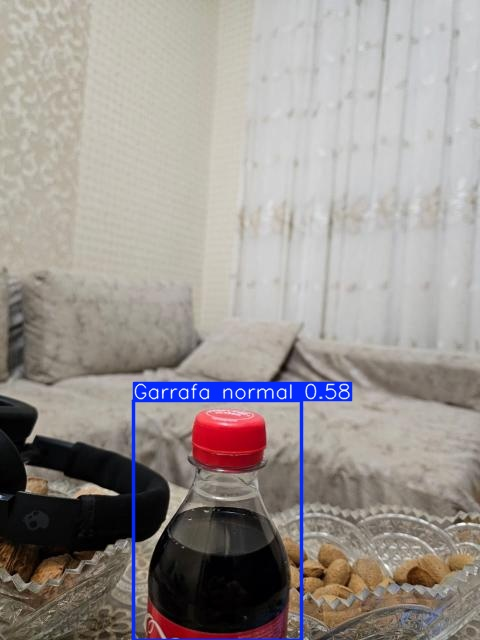


🖼 IMG-20250628-WA0889_jpg.rf.4ea73afbfefdb92bb691071e7a533731.jpg


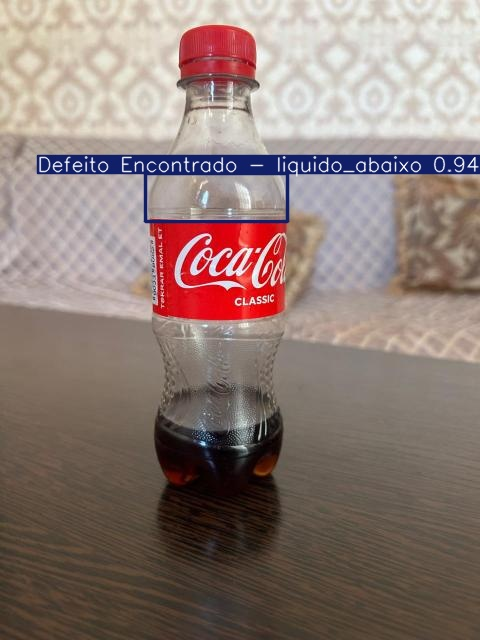


🖼 IMG-20250628-WA0193_jpg.rf.17b7180754ce0e7d7cd7a0a2bcab1d85.jpg


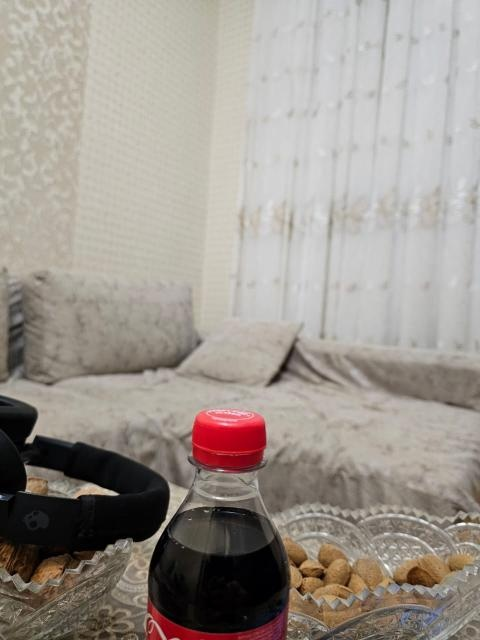


🖼 IMG-20250628-WA0244_jpg.rf.acfc27cc82afe2de7714c0dede958c47.jpg


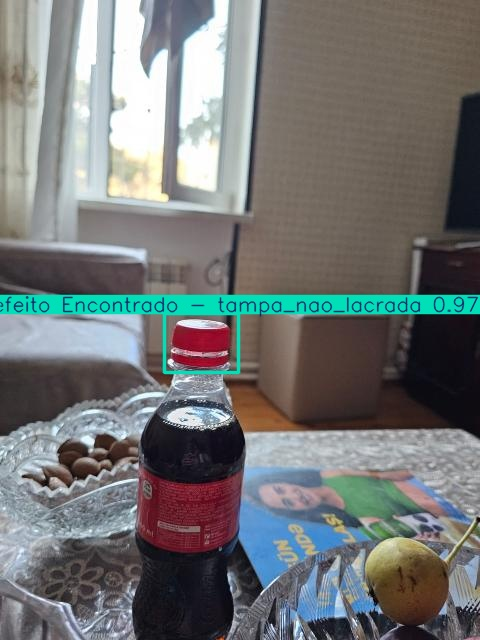


🖼 IMG-20250628-WA0046_jpg.rf.ea6adb895296d8e6fd45cff9306caef3.jpg


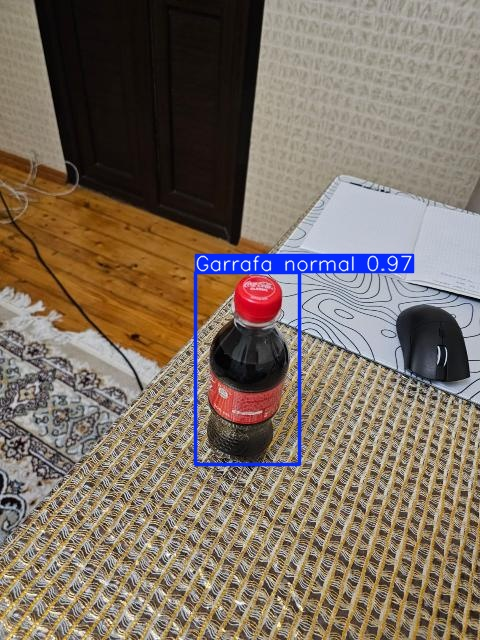


🖼 IMG-20250703-WA0123_jpg.rf.d0fae05d6d5d5aab7e2604146c62153c.jpg


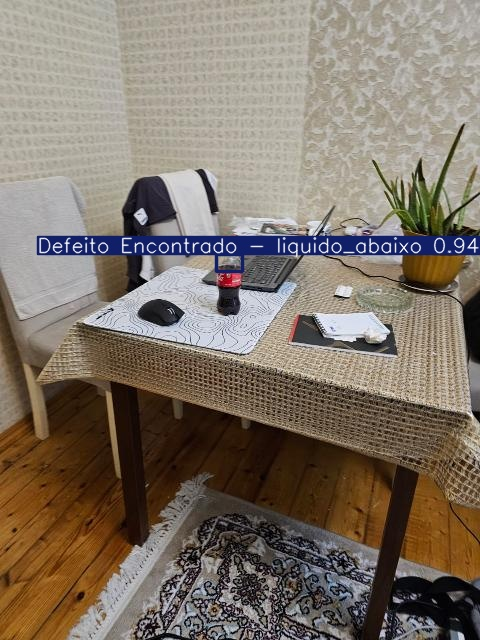

In [ ]:
test_images_dir = os.path.join(LOCAL_DATASET, "test", "images")

if os.path.exists(test_images_dir):
    test_imgs = glob.glob(os.path.join(test_images_dir, "*.jpg"))[:5]  # show first 5
    if test_imgs:
        pred_results = eval_model.predict(
            source    = test_imgs,
            imgsz     = 640,
            conf      = 0.25,
            iou       = 0.45,
            save      = True,
            project   = RUNS_DIR,
            name      = "cocacola_predictions",
            exist_ok  = True,
        )

        pred_dir = str(pred_results[0].save_dir)
        for img_path in glob.glob(os.path.join(pred_dir, "*.jpg")):
            print(f"\n🖼 {os.path.basename(img_path)}")
            display(Image(img_path))
    else:
        print("No .jpg images found in test/images")
else:
    print(f"Test folder not found: {test_images_dir}")

## 9. Export Model (optional)

In [ ]:
# Export to ONNX for deployment
# Other formats: 'torchscript', 'tflite', 'coreml', 'engine' (TensorRT)

export_model = YOLO(best_weights)
export_path = export_model.export(format="onnx", imgsz=640, dynamic=True)
print(f"\n📦 Exported model: {export_path}")

# Copy exported model to Drive
export_dest = os.path.join(RUNS_DIR, "cocacola_yolo26m", "best.onnx")
os.makedirs(os.path.dirname(export_dest), exist_ok=True)
shutil.copy(export_path, export_dest)
print(f"✅ ONNX saved to Drive: {export_dest}")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26m summary (fused): 132 layers, 20,353,307 parameters, 0 gradients, 67.9 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m_inspecao_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 332ms
Prepared 4 packages in 1.76s
Installed 4 packages in 296ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 10.3s, saved as '/content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m_inspecao_v1/weights/best.onnx' (78.3 MB)

Export complete (12.5s)
Results saved to /content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m_inspecao_v1/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m_inspecao_v1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m_inspecao_v1/weights/best.onnx imgsz=640 data=/content/datasets/cocacola/data.yaml  
Visualize:       https://netron.app

📦 Exported model: /content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m_inspecao_v1/weights/best.onnx
✅ ONNX saved to Drive: /content/drive/MyDrive/Projeto Especializado/runs/cocacola_yolo26m/best.onnx


---
## Summary

| Item | Location |
|------|----------|
| Best weights (`.pt`) | `My Drive/Projeto Especializado/runs/cocacola_yolo26m/weights/best.pt` |
| Last weights (`.pt`) | `My Drive/Projeto Especializado/runs/cocacola_yolo26m/weights/last.pt` |
| Training curves | `My Drive/Projeto Especializado/runs/cocacola_yolo26m/results.png` |
| Predictions | `My Drive/Projeto Especializado/runs/cocacola_predictions/` |
| ONNX export | `My Drive/Projeto Especializado/runs/cocacola_yolo26m/best.onnx` |
